# Clinical NLP Pipeline — End-to-End Demo

**Predicting 30-Day Hospital Readmission from Discharge Summaries**

This notebook runs the full pipeline:
1. **Data Generation & Loading** — Synthetic MIMIC-IV-style clinical data
2. **Preprocessing** — Clinical text cleaning, tokenization, phrase detection
3. **Topic Modeling** — LDA topic discovery on discharge notes
4. **Feature Engineering** — TF-IDF, topic distributions, structured features, text statistics
5. **Prediction** — Logistic Regression, Random Forest, XGBoost, LightGBM
6. **Fairness Audit** — Disparity analysis across gender, insurance, age group
7. **Visualization** — Publication-quality figures

In [1]:
import sys, os, logging, warnings
from pathlib import Path

# Project root setup
PROJECT_ROOT = Path(os.getcwd()).parent if "notebooks" in os.getcwd() else Path(os.getcwd())
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

# Logging & warnings
logging.basicConfig(level=logging.INFO, format="%(asctime)s — %(levelname)s — %(message)s")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import yaml
import numpy as np
import pandas as pd

with open("config/config.yaml") as f:
    config = yaml.safe_load(f)

print(f"Project root: {PROJECT_ROOT}")
print("Config loaded successfully.")

2026-04-06 08:27:15,185 — INFO — NumExpr defaulting to 8 threads.


Project root: c:\Users\USER\Desktop\AkashGroup\ClinicalNLP
Config loaded successfully.


## 1. Data Generation & Loading

Generate synthetic clinical data (patients, admissions, discharge notes) mimicking the MIMIC-IV schema, then load and merge into a single analysis-ready DataFrame.

In [2]:
from src.generate_synthetic_data import run as generate_data
from src.data_loader import load_all, get_data_summary

# Generate synthetic data (200 patients -> ~300+ notes)
generate_data(output_dir="data", n_patients=200)

# Load & merge all tables
df = load_all(config, use_synthetic=True)
summary = get_data_summary(df)

print(f"\nDataset shape: {df.shape}")
df.head(3)

2026-04-06 08:27:15,782 — INFO — Generating 200 synthetic patients...
2026-04-06 08:27:15,791 — INFO — Generating admissions with 18% readmission rate...
2026-04-06 08:27:15,899 — INFO — Admissions generated: 332 rows
2026-04-06 08:27:15,900 — INFO — Generating synthetic discharge notes...
2026-04-06 08:27:16,006 — INFO — Discharge notes generated: 332 rows
2026-04-06 08:27:16,045 — INFO — Saved patients (200), admissions (332), notes (332)
2026-04-06 08:27:16,045 — INFO — Readmission rate (eligible): 15.9%
2026-04-06 08:27:16,045 — INFO — Files saved to: C:\Users\USER\Desktop\AkashGroup\ClinicalNLP\data
2026-04-06 08:27:16,055 — INFO — Loading discharge notes from data\synthetic_discharge.csv ...
2026-04-06 08:27:16,091 — INFO — Discharge summaries found: 332
2026-04-06 08:27:16,092 — INFO — Loading admissions from data\synthetic_admissions.csv ...
2026-04-06 08:27:16,121 — INFO — Admissions loaded: 332 rows
2026-04-06 08:27:16,123 — INFO — Loading patients from data\synthetic_patient

--------------------------------------------------
DATASET SUMMARY
--------------------------------------------------
  Total notes          : 332
  Unique patients      : 200
  Unique admissions    : 332
  Readmission rate     : 15.9%
  Avg note length      : 420 words

  Gender distribution  : {'M': 180, 'F': 152}
  Age (mean/median)    : 64.3 / 70.0 yrs  [19–89]
  Age groups           : {'65+': 201, '40-65': 95, '<40': 36}
  Insurance types      : {'Medicare': 141, 'Other': 110, 'Medicaid': 81}
--------------------------------------------------

Dataset shape: (332, 28)


,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,text,admittime,dischtime,...,edouttime,hospital_expire_flag,readmission_30day,gender,anchor_age,anchor_year,anchor_year_group,dod,los_days,age_group
0,30000000,10000000,20000000,Discharge summary,1,2111-10-12 15:56:19,2111-10-12 15:56:19,Admission Date: ___\nDischarge Date: ___\nDate...,2111-10-06 15:56:19,2111-10-12 15:56:19,...,2111-10-06 15:56:19,0,0,M,75,2108,2106-2108,NaN,6.0,65+
1,30000001,10000000,20000001,Discharge summary,1,2112-09-22 15:56:19,2112-09-22 15:56:19,Admission Date: ___\nDischarge Date: ___\nDate...,2112-09-16 15:56:19,2112-09-22 15:56:19,...,2112-09-16 15:56:19,0,1,M,75,2108,2106-2108,NaN,6.0,65+
2,30000002,10000000,20000002,Discharge summary,1,2112-10-17 15:56:19,2112-10-17 15:56:19,Admission Date: ___\nDischarge Date: ___\nDate...,2112-10-10 15:56:19,2112-10-17 15:56:19,...,2112-10-10 15:56:19,0,-1,M,75,2108,2106-2108,NaN,7.0,65+


## 2. Preprocessing

Clean clinical text (remove PHI patterns, dates, special characters), tokenize with NLTK, and prepare documents for topic modeling and feature extraction.

In [3]:
from src.preprocess import build_preprocessing_pipeline

processed = build_preprocessing_pipeline(df, config=config, use_scispacy=False, use_phrases=False)

print(f"Processed shape: {processed.shape}")
print(f"Avg tokens per note: {processed['num_tokens'].mean():.1f}")
print(f"\nSample cleaned text (first 200 chars):")
print(processed["cleaned_text"].iloc[0][:200])
print(f"\nSample tokens: {processed['tokens'].iloc[0][:15]}")

2026-04-06 08:27:16,223 — INFO — Step 1/4 — removing unwanted sections from 332 notes ...
2026-04-06 08:27:16,288 — INFO — Step 2/4 — cleaning text ...
2026-04-06 08:27:16,445 — INFO — Filtered 0 notes outside length bounds — 332 remaining
2026-04-06 08:27:16,445 — INFO — Step 3/4 — tokenizing 332 notes (use_scispacy=False) ...
2026-04-06 08:27:18,950 — INFO — Downloading NLTK resource: wordnet
2026-04-06 08:27:19,274 — INFO — Downloading NLTK resource: averaged_perceptron_tagger
2026-04-06 08:52:29,673 — INFO — Step 4/4 — skipping phrase detection.
2026-04-06 08:52:29,707 — INFO — Preprocessing complete — vocab size: 447, avg tokens/doc: 191.8


Processed shape: (332, 31)
Avg tokens per note: 191.8

Sample cleaned text (first 200 chars):
admission date: 
discharge date: 
date of birth: 
sex: m
service: medicine
allergies: no known allergies
attending: md

chief complaint:
aki

history of present illness:
the patient is a 75-year-old m

Sample tokens: ['birth', 'sex', 'service', 'medicine', 'allergy', 'known', 'allergy', 'attending', 'md', 'chief', 'complaint', 'aki', 'present', 'illness', 'male']


## 3. Topic Modeling (LDA)

Discover latent clinical topics in discharge notes using Latent Dirichlet Allocation. We grid-search over topic counts and select the best by coherence score.

In [13]:
from src.topic_model import run_lda_pipeline

# Filter to eligible notes (readmission label >= 0)
eligible_mask = processed["readmission_30day"] >= 0
eligible_df = processed[eligible_mask].reset_index(drop=True)
tokenized_docs = eligible_df["tokens"].apply(lambda t: t if isinstance(t, list) else []).tolist()

print(f"Eligible documents for topic modeling: {len(tokenized_docs)}")

# Run LDA pipeline (grid search over num_topics)
lda_results = run_lda_pipeline(tokenized_docs, config=config)

print(f"\nBest number of topics: {lda_results['best_num_topics']}")
print(f"Coherence scores: {lda_results['coherence_scores']}")
print(f"\nTopic labels:")
for tid, label in lda_results["topic_labels"].items():
    words = ", ".join(w for w, _ in lda_results["topic_words"][tid][:6])
    print(f"  Topic {tid:2d} [{label}]: {words} ...")

2026-04-06 08:59:12,841 — INFO — Building dictionary and corpus ...
2026-04-06 08:59:12,843 — INFO — adding document #0 to Dictionary<0 unique tokens: []>
2026-04-06 08:59:12,884 — INFO — built Dictionary<445 unique tokens: ['activity', 'acute', 'administered', 'admitted', 'advised']...> from 132 documents (total 25370 corpus positions)
2026-04-06 08:59:12,888 — INFO — Dictionary lifecycle event {'msg': "built Dictionary<445 unique tokens: ['activity', 'acute', 'administered', 'admitted', 'advised']...> from 132 documents (total 25370 corpus positions)", 'datetime': '2026-04-06T08:59:12.887613', 'gensim': '4.4.0', 'python': '3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'created'}
2026-04-06 08:59:12,891 — INFO — discarding 89 tokens: [('activity', 132), ('admitted', 132), ('advised', 132), ('allergy', 132), ('approximately', 132), ('atn', 4), ('attending', 132), ('began', 132), ('birth', 132), ('bnp

Eligible documents for topic modeling: 132


2026-04-06 08:59:13,184 — INFO — -6.500 per-word bound, 90.5 perplexity estimate based on a held-out corpus of 132 documents with 13582 words
2026-04-06 08:59:13,184 — INFO — PROGRESS: pass 0, at document #132/132
2026-04-06 08:59:13,372 — INFO — optimized alpha [np.float32(0.23274508), np.float32(0.23662344), np.float32(0.21956158), np.float32(0.13585228), np.float32(0.09519867)]
2026-04-06 08:59:13,372 — INFO — topic #0 (0.233): 0.020*"male" + 0.015*"use" + 0.015*"iv" + 0.013*"disease" + 0.011*"female" + 0.010*"stroke" + 0.009*"alcohol" + 0.009*"kidney" + 0.009*"failure" + 0.008*"former"
2026-04-06 08:59:13,372 — INFO — topic #1 (0.237): 0.021*"disease" + 0.016*"iv" + 0.014*"male" + 0.013*"copd" + 0.013*"female" + 0.013*"pulmonary" + 0.012*"use" + 0.010*"former" + 0.010*"general" + 0.010*"acute"
2026-04-06 08:59:13,382 — INFO — topic #2 (0.220): 0.017*"female" + 0.016*"disease" + 0.015*"iv" + 0.013*"use" + 0.013*"male" + 0.010*"pulmonary" + 0.009*"right" + 0.008*"sepsis" + 0.008*"gen


Best number of topics: 10
Coherence scores: {5: np.float64(0.414), 10: np.float64(0.5661), 15: np.float64(0.5563), 20: np.float64(0.5183)}

Topic labels:
  Topic  0 [Cardiovascular]: male, failure, heart, ejection, fraction, reduced ...
  Topic  1 [Respiratory / Pulmonary]: copd, male, disease, iv, pulmonary, acute ...
  Topic  2 [Cardiovascular (2)]: pneumonia, culture, disease, female, use, iv ...
  Topic  3 [Neurological]: stroke, therapy, initiated, acute, neurology, female ...
  Topic  4 [Gastrointestinal]: gi, iv, bleed, female, access, red ...
  Topic  5 [Infection / Sepsis]: sepsis, vasopressor, culture, disease, source, male ...
  Topic  6 [Cardiovascular (3)]: heart, failure, chronic, kidney, disease, diabetes ...
  Topic  7 [Endocrine / Metabolic]: insulin, dka, male, diabetic, needed, repleted ...
  Topic  8 [Neurological (2)]: altered, status, mental, anemia, ppd, current ...
  Topic  9 [Renal / Kidney]: aki, kidney, disease, male, acute, nephrology ...


In [14]:
# Topic summary table
lda_results["topics_df"]

,topic_id,label,top_words,top_word_weights
0,0,Cardiovascular,"male, failure, heart, ejection, fraction, redu...","[0.0252, 0.0196, 0.0195, 0.0175, 0.0175, 0.017..."
1,1,Respiratory / Pulmonary,"copd, male, disease, iv, pulmonary, acute, ant...","[0.0291, 0.0189, 0.0169, 0.0159, 0.0134, 0.011..."
2,2,Cardiovascular (2),"pneumonia, culture, disease, female, use, iv, ...","[0.0267, 0.0181, 0.015, 0.0149, 0.0143, 0.0141..."
3,3,Neurological,"stroke, therapy, initiated, acute, neurology, ...","[0.0485, 0.034, 0.0233, 0.0153, 0.0152, 0.0149..."
4,4,Gastrointestinal,"gi, iv, bleed, female, access, red, hemoglobin...","[0.0336, 0.0304, 0.0213, 0.0204, 0.017, 0.017,..."
5,5,Infection / Sepsis,"sepsis, vasopressor, culture, disease, source,...","[0.0537, 0.0269, 0.023, 0.0215, 0.0173, 0.0171..."
6,6,Cardiovascular (3),"heart, failure, chronic, kidney, disease, diab...","[0.0473, 0.0469, 0.0376, 0.031, 0.0309, 0.0277..."
7,7,Endocrine / Metabolic,"insulin, dka, male, diabetic, needed, repleted...","[0.041, 0.0365, 0.0164, 0.0147, 0.0147, 0.0147..."
8,8,Neurological (2),"altered, status, mental, anemia, ppd, current,...","[0.1887, 0.1886, 0.1886, 0.0312, 0.0189, 0.017..."
9,9,Renal / Kidney,"aki, kidney, disease, male, acute, nephrology,...","[0.021, 0.0198, 0.0172, 0.017, 0.0162, 0.0158,..."


## 4. Feature Engineering

Build multiple feature representations:
- **TF-IDF** — Bag-of-words text representation
- **Topic distributions** — LDA document-topic probabilities
- **Structured** — Demographics, admission info, prior utilization
- **Text statistics** — Note length, negations, section count
- **Combined** — All of the above stacked

In [15]:
from src.feature_engineer import build_feature_sets

feature_sets = build_feature_sets(processed, lda_results=lda_results, config=config)

print("Feature sets built:")
for key in ["tfidf", "topic_lda", "structured", "text_stats", "combined"]:
    entry = feature_sets.get(key)
    if entry and entry.get("X") is not None:
        shape = entry["X"].shape
        print(f"  {key:20s} — shape: {shape}")

print(f"\nLabels: {len(feature_sets['label'])} samples")
print(f"  Readmitted: {feature_sets['label'].sum()} ({feature_sets['label'].mean()*100:.1f}%)")

2026-04-06 09:00:26,452 — INFO — Building TF-IDF features ...
2026-04-06 09:00:26,522 — INFO — TF-IDF fitted — shape: (132, 1129), vocab: 1129
2026-04-06 09:00:26,524 — INFO — Building LDA topic features ...
2026-04-06 09:00:26,599 — INFO — LDA topic features — shape: (132, 10)
2026-04-06 09:00:26,599 — INFO — Building structured features ...
2026-04-06 09:00:26,695 — INFO — Structured features — shape: (132, 12), features: ['age', 'gender_male', 'insurance_medicare', 'insurance_medicaid', 'insurance_other', 'admtype_emergency', 'admtype_elective', 'admtype_urgent', 'log_los', 'num_prior_admissions', 'days_since_last_admission', 'prior_expire_flag']
2026-04-06 09:00:26,695 — INFO — Building text statistics features ...
2026-04-06 09:00:26,785 — INFO — Text statistics features — shape: (132, 5), features: ['note_length_words', 'num_negations', 'num_section_headers', 'avg_word_length', 'type_token_ratio']
2026-04-06 09:00:26,787 — INFO — Building combined feature set ...
2026-04-06 09:00

Feature sets built:
  tfidf                — shape: (132, 1129)
  topic_lda            — shape: (132, 10)
  structured           — shape: (132, 12)
  text_stats           — shape: (132, 5)
  combined             — shape: (132, 1156)

Labels: 132 samples
  Readmitted: 21 (15.9%)


## 5. Prediction Pipeline

Train Logistic Regression, Random Forest, XGBoost, and LightGBM on each feature set. Evaluate with ROC-AUC, F1, PR-AUC, and cross-validation.

In [16]:
from src.predict import run_prediction_pipeline

prediction_results = run_prediction_pipeline(feature_sets, config=config)

# Summary table
display_cols = ["model", "feature_type", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
results_df = prediction_results["results_df"]
results_df[display_cols].sort_values("roc_auc", ascending=False)

2026-04-06 09:00:35,442 — INFO — ============================================================
2026-04-06 09:00:35,444 — INFO — Feature set: tfidf — shape (132, 1129)
2026-04-06 09:00:35,445 — INFO — ============================================================
2026-04-06 09:00:35,451 — INFO — Split — train: 91, val: 14, test: 27  (pos rate: train=16.5%, val=14.3%, test=14.8%)
2026-04-06 09:00:35,451 — INFO — --- logistic_regression + tfidf ---
2026-04-06 09:00:35,470 — INFO — Trained logistic_regression.
2026-04-06 09:00:35,504 — INFO — logistic_regression — Acc: 0.889 | F1: 0.667 | ROC-AUC: 0.837 | PR-AUC: 0.663
2026-04-06 09:00:35,727 — INFO — Optimal threshold (metric=f1): 0.51 (score=0.7500)
2026-04-06 09:00:35,732 — INFO — --- random_forest + tfidf ---
2026-04-06 09:00:36,133 — INFO — Trained random_forest.
2026-04-06 09:00:36,177 — INFO — random_forest — Acc: 0.852 | F1: 0.000 | ROC-AUC: 0.543 | PR-AUC: 0.489
2026-04-06 09:00:36,391 — INFO — Optimal threshold (metric=f1): 0.35 (sc

,model,feature_type,accuracy,precision,recall,f1,roc_auc,pr_auc
0,logistic_regression,tfidf,0.8889,0.6000,0.75,0.6667,0.8370,0.6630
2,xgboost,tfidf,0.8889,0.6667,0.50,0.5714,0.8152,0.5863
4,logistic_regression,topic_distribution,0.7778,0.3750,0.75,0.5000,0.8152,0.5347
14,xgboost,combined,0.8519,0.5000,0.25,0.3333,0.7500,0.5500
12,logistic_regression,combined,0.7778,0.3333,0.50,0.4000,0.6957,0.5191
15,lightgbm,combined,0.7037,0.1667,0.25,0.2000,0.6630,0.4213
6,xgboost,topic_distribution,0.7778,0.2500,0.25,0.2500,0.6196,0.2872
3,lightgbm,tfidf,0.8519,0.0000,0.00,0.0000,0.6033,0.1906
7,lightgbm,topic_distribution,0.8519,0.0000,0.00,0.0000,0.5598,0.2101
13,random_forest,combined,0.8519,0.0000,0.00,0.0000,0.5543,0.5728


In [17]:
# Best model summary
best = prediction_results["best"]
print(f"Best model: {best.get('model')} + {best.get('feature_type')}")
print(f"  ROC-AUC: {best.get('roc_auc', 0):.4f}")
print(f"  F1:      {best.get('f1', 0):.4f}")
print(f"  PR-AUC:  {best.get('pr_auc', 0):.4f}")

# Cross-validation results
if prediction_results["cv_results"]:
    print("\nCross-validation results:")
    for cv in prediction_results["cv_results"]:
        print(f"  {cv['model']} + {cv['feature_type']} — "
              f"F1: {cv['f1_mean']:.3f}±{cv['f1_std']:.3f} | "
              f"ROC-AUC: {cv['roc_auc_mean']:.3f}±{cv['roc_auc_std']:.3f}")

Best model: logistic_regression + tfidf
  ROC-AUC: 0.8370
  F1:      0.6667
  PR-AUC:  0.6630

Cross-validation results:
  logistic_regression + tfidf — F1: 0.405±0.211 | ROC-AUC: 0.707±0.138
  logistic_regression + topic_distribution — F1: 0.296±0.111 | ROC-AUC: 0.617±0.197
  logistic_regression + structured — F1: 0.261±0.060 | ROC-AUC: 0.473±0.129
  xgboost + combined — F1: 0.160±0.219 | ROC-AUC: 0.539±0.099


## 6. Fairness Audit

Evaluate prediction fairness across protected attributes (gender, insurance, age group) using Fairlearn. We check for demographic parity, equalized odds, and false positive/negative rate disparities.

In [18]:
from src.fairness import run_fairness_audit

# Use the best model's predictions for the fairness audit
best_model_name = best.get("model", "logistic_regression")
best_feat_type = best.get("feature_type", "structured")
best_model = prediction_results["models"].get((best_model_name, best_feat_type))
best_splits = prediction_results["splits"].get(best_feat_type)

if best_model and best_splits:
    y_test = best_splits["y_test"]
    X_test = best_splits["X_test"]
    y_prob = best_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    # Get the eligible DataFrame aligned with the test split
    eligible_df = feature_sets["eligible_df"]

    # Reconstruct test indices via the split
    from src.predict import split_data
    test_size = config.get("prediction", {}).get("test_size", 0.2)
    val_size = config.get("prediction", {}).get("val_size", 0.1)
    feat_entry = feature_sets.get(
        {"tfidf": "tfidf", "topic_distribution": "topic_lda",
         "structured": "structured", "combined": "combined"}.get(best_feat_type, best_feat_type)
    )
    X_full = feat_entry["X"]
    labels = feature_sets["label"]

    from sklearn.model_selection import train_test_split
    _, X_test_idx, _, _ = train_test_split(
        np.arange(len(labels)), labels,
        test_size=test_size, stratify=labels, random_state=42,
    )

    # Build protected attributes DataFrame for test set
    protected_cols = config.get("fairness", {}).get("protected_attributes", ["gender", "insurance", "age_group"])
    protected_df = eligible_df.loc[X_test_idx, protected_cols].reset_index(drop=True)

    fairness_results = run_fairness_audit(
        y_true=y_test,
        y_pred=y_pred,
        y_prob=y_prob,
        protected_df=protected_df,
        config=config,
    )
else:
    print("Best model not available for fairness audit.")

2026-04-06 09:01:20,787 — INFO — Group metrics for 'gender':
        n_samples  positive_rate  accuracy  precision  recall   f1     fpr  fnr
gender                                                                         
F              15         0.1333    0.9333     0.6667     1.0  0.8  0.0769  0.0
M              12         0.1667    0.8333     0.5000     0.5  0.5  0.1000  0.5
2026-04-06 09:01:20,916 — INFO — Fairness [gender] — DPD: 0.0333 | EOD: 0.5000 | FPR diff: 0.0231 | FNR diff: 0.5000
2026-04-06 09:01:21,001 — INFO — Group metrics for 'insurance':
           n_samples  positive_rate  accuracy  precision  recall      f1     fpr     fnr
insurance                                                                               
Medicaid           7         0.0000    0.8571        0.0  0.0000  0.0000  0.1429  0.0000
Medicare           9         0.3333    0.8889        1.0  0.6667  0.8000  0.0000  0.3333
Other             11         0.0909    0.9091        0.5  1.0000  0.6667  0.1000  


FAIRNESS AUDIT REPORT

--- GENDER ---
        n_samples  positive_rate  accuracy  precision  recall   f1     fpr  fnr
gender                                                                         
F              15         0.1333    0.9333     0.6667     1.0  0.8  0.0769  0.0
M              12         0.1667    0.8333     0.5000     0.5  0.5  0.1000  0.5

--- INSURANCE ---
           n_samples  positive_rate  accuracy  precision  recall      f1     fpr     fnr
insurance                                                                               
Medicaid           7         0.0000    0.8571        0.0  0.0000  0.0000  0.1429  0.0000
Medicare           9         0.3333    0.8889        1.0  0.6667  0.8000  0.0000  0.3333
Other             11         0.0909    0.9091        0.5  1.0000  0.6667  0.1000  0.0000

--- AGE_GROUP ---
           n_samples  positive_rate  accuracy  precision  recall    f1     fpr   fnr
age_group                                                                

In [19]:
# Fairness summary
if fairness_results:
    fairness_results["summary_df"]

## 7. Visualization

Generate all publication-quality figures and save to `results/figures/`.

In [20]:
from src.visualize import generate_all_figures

# Add readmission labels to lda_results for the heatmap
lda_results["readmission_labels"] = feature_sets["label"]

saved_figures = generate_all_figures(
    merged_df=df,
    prediction_results=prediction_results,
    lda_results=lda_results,
    fairness_results=fairness_results if "fairness_results" in dir() else None,
    config=config,
)

print(f"\nGenerated {len(saved_figures)} figures:")
for fig_path in saved_figures:
    print(f"  {fig_path}")

2026-04-06 09:01:33,313 — INFO — Generating dataset distribution plots ...
2026-04-06 09:01:35,012 — INFO — Saved figure: results\figures\demographics.png
2026-04-06 09:01:35,967 — INFO — Saved figure: results\figures\note_length_distribution.png
2026-04-06 09:01:35,967 — INFO — Generating topic modeling plots ...
2026-04-06 09:01:36,424 — INFO — Saved figure: results\figures\coherence_scores.png
2026-04-06 09:01:42,185 — INFO — Saved figure: results\figures\topic_word_clouds.png
2026-04-06 09:01:42,554 — INFO — Saved figure: results\figures\topic_readmission_heatmap.png
2026-04-06 09:01:42,554 — INFO — Generating prediction performance plots ...
2026-04-06 09:01:43,610 — INFO — Saved figure: results\figures\roc_curves.png
2026-04-06 09:01:44,800 — INFO — Saved figure: results\figures\pr_curves.png
2026-04-06 09:01:54,089 — INFO — Saved figure: results\figures\confusion_matrices.png
2026-04-06 09:01:55,205 — INFO — Saved figure: results\figures\model_comparison.png
2026-04-06 09:02:01,


Generated 12 figures:
  results\figures\demographics.png
  results\figures\note_length_distribution.png
  results\figures\coherence_scores.png
  results\figures\topic_word_clouds.png
  results\figures\topic_readmission_heatmap.png
  results\figures\roc_curves.png
  results\figures\pr_curves.png
  results\figures\confusion_matrices.png
  results\figures\model_comparison.png
  results\figures\feature_importance.png
  results\figures\fairness_disparity.png
  results\figures\fairness_group_metrics.png



  Demographics


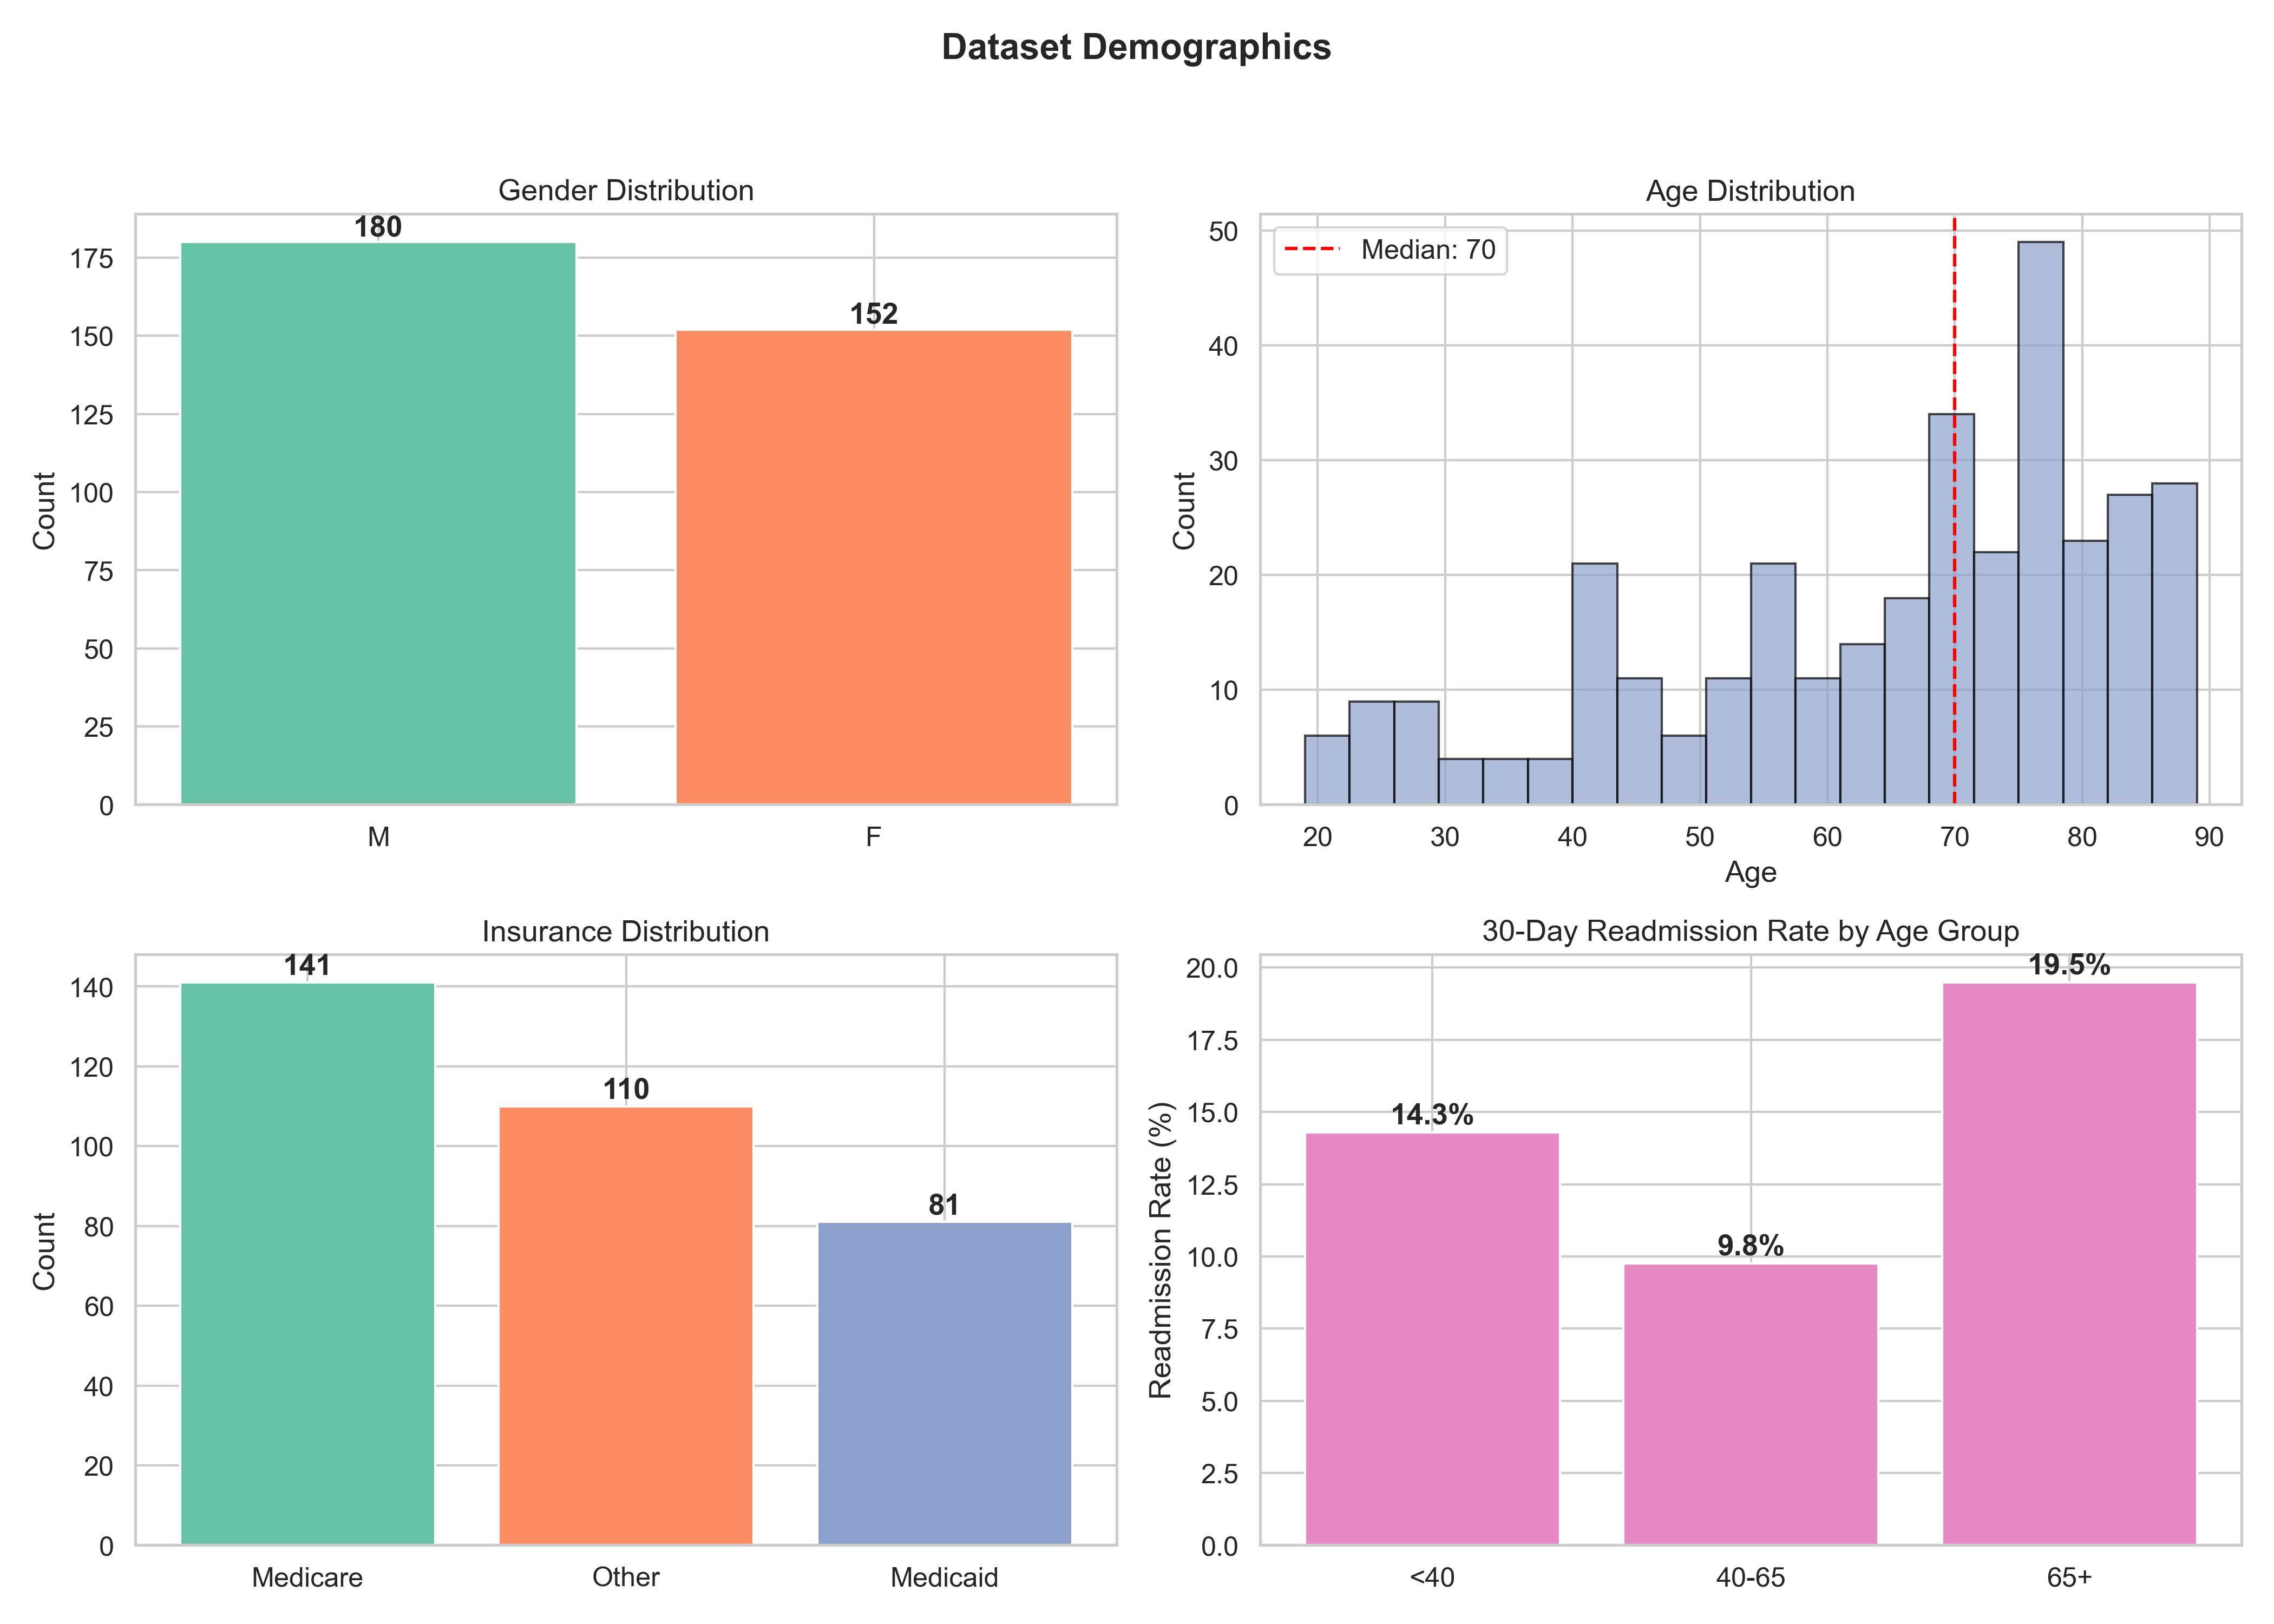


  Roc Curves


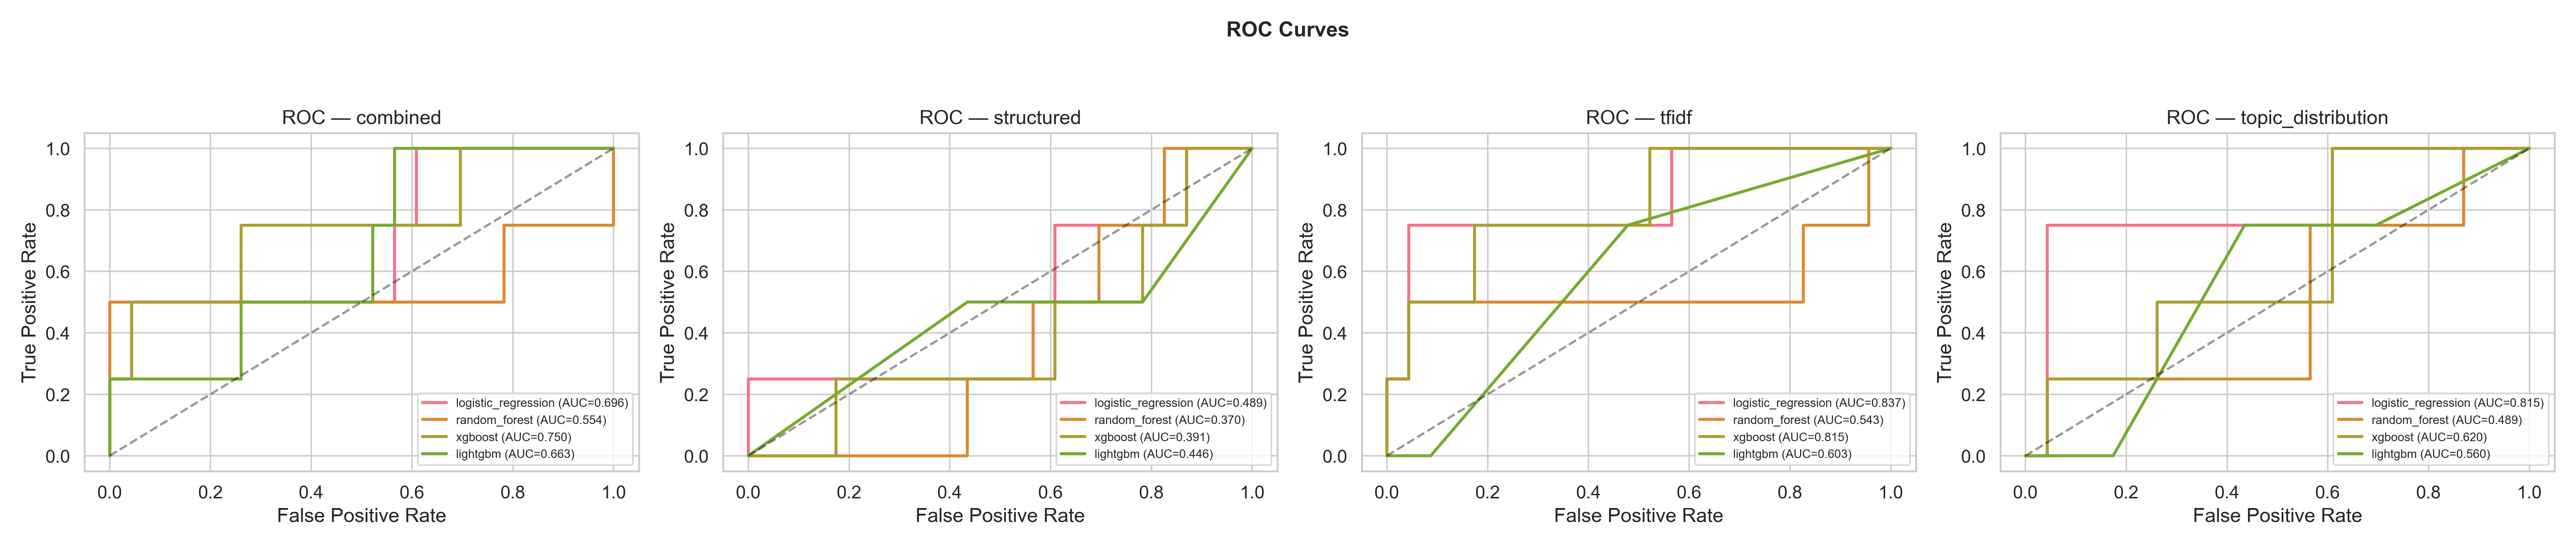


  Model Comparison


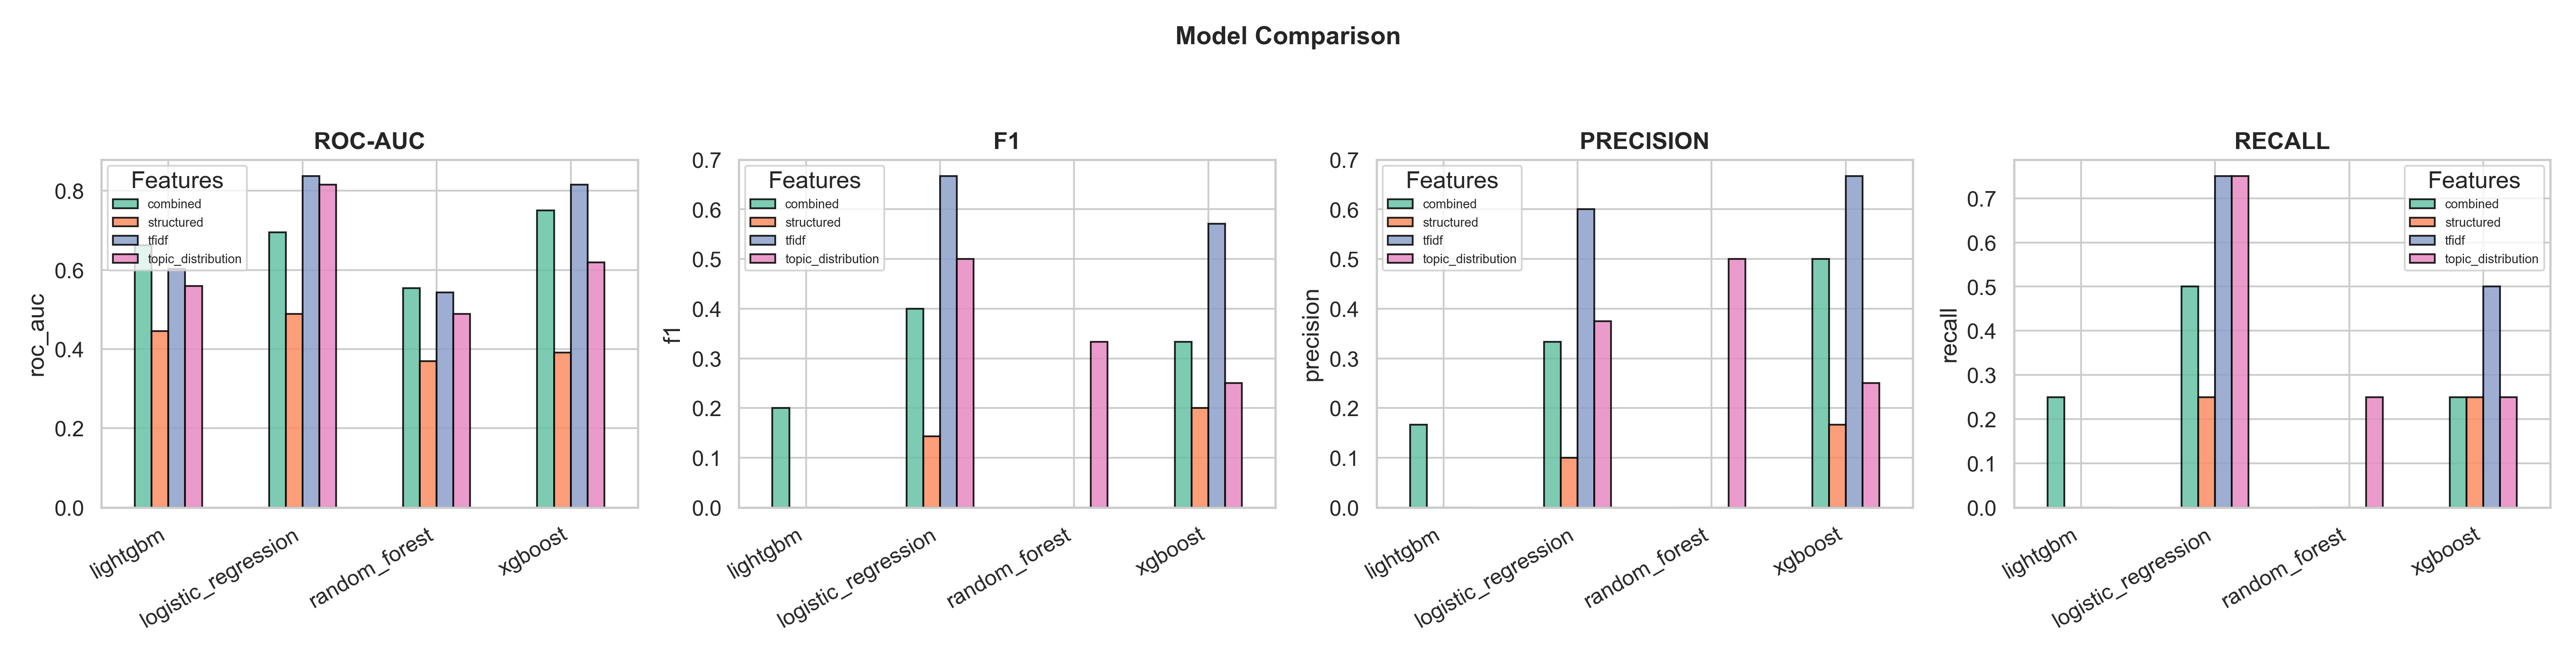


  Fairness Disparity


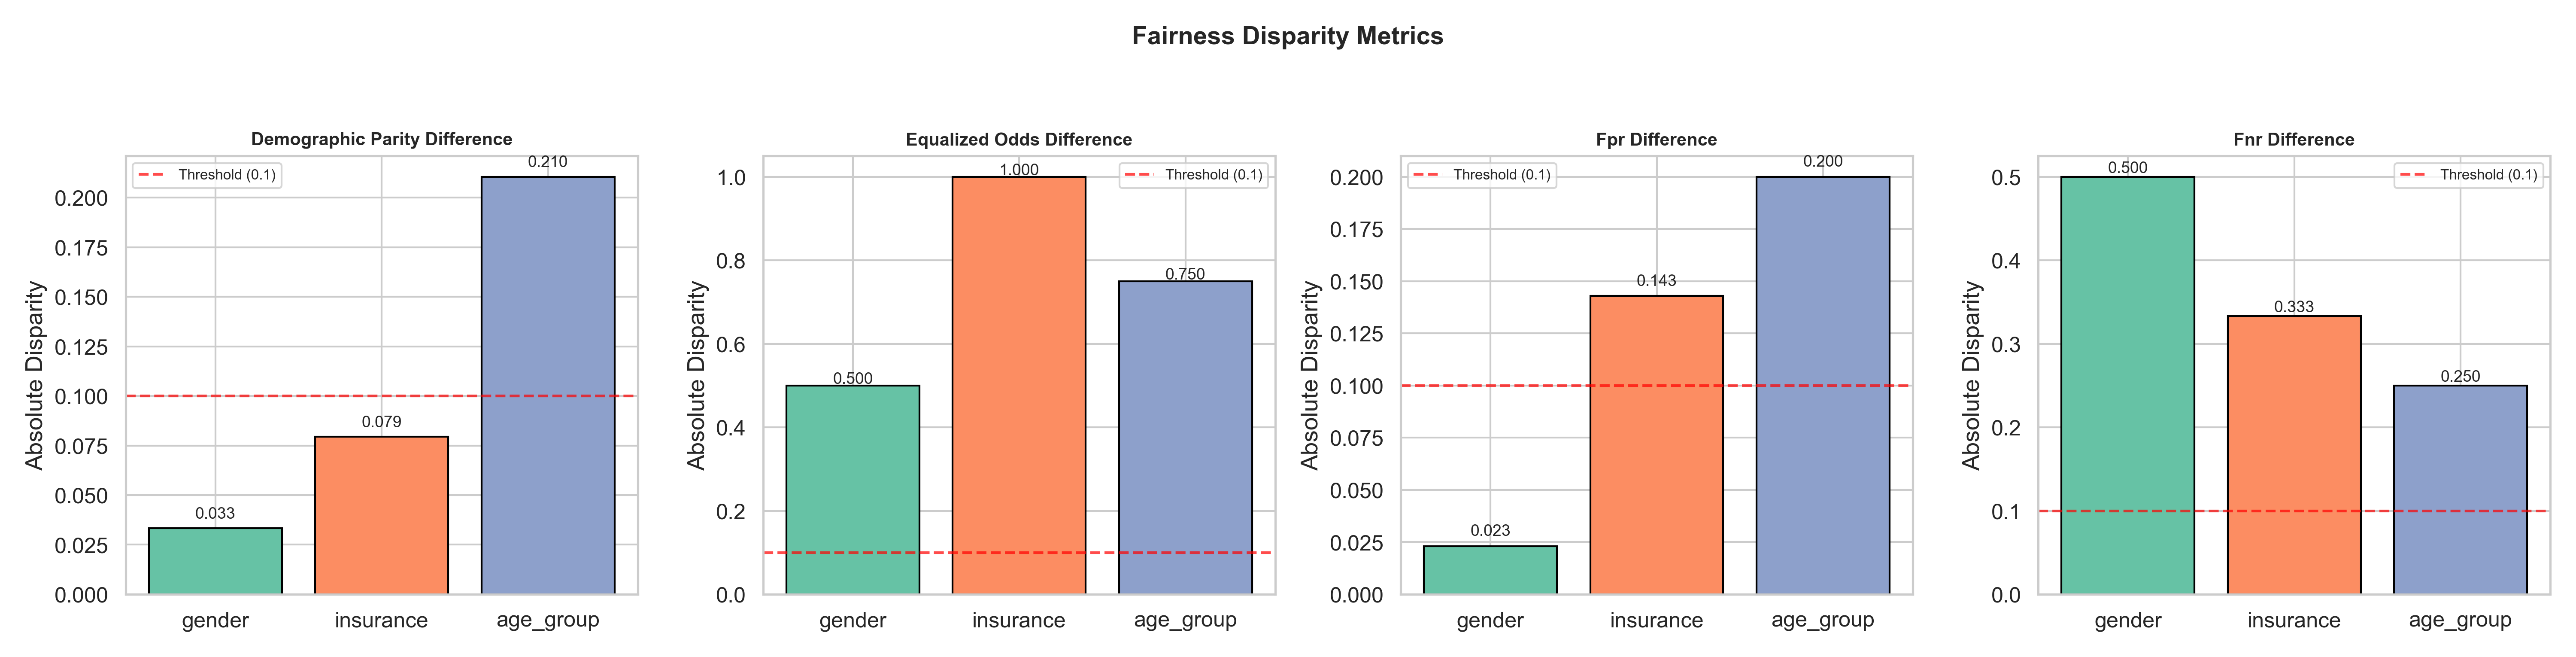

In [12]:
# Display key figures inline
from IPython.display import Image, display

key_figures = ["demographics", "roc_curves", "model_comparison", "fairness_disparity"]
for name in key_figures:
    fig_path = f"results/figures/{name}.png"
    if Path(fig_path).exists():
        print(f"\n{'='*60}")
        print(f"  {name.replace('_', ' ').title()}")
        print(f"{'='*60}")
        display(Image(filename=fig_path, width=800))

## Summary

| Component | Details |
|-----------|---------|
| **Data** | Synthetic MIMIC-IV (200 patients, ~300+ notes) |
| **Preprocessing** | PHI removal, NLTK tokenization, clinical stopwords |
| **Topic Modeling** | LDA with coherence-based topic selection |
| **Features** | TF-IDF, topic distributions, structured, text stats, combined |
| **Models** | Logistic Regression, Random Forest, XGBoost, LightGBM |
| **Fairness** | Demographic parity, equalized odds, FPR/FNR disparity |
| **Output** | Publication-quality figures in `results/figures/` |